In [1]:
import sys
# 
print(sys.executable)

C:\Users\Anupa\anaconda3\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import mlxtend

print("Everything imported successfully")

Everything imported successfully


In [3]:
or_data=pd.DataFrame()
and_data=pd.DataFrame()
xor_data=pd.DataFrame()

In [4]:
or_data['input1']=[1,1,0,0]
or_data['input2']=[1,0,1,0]
or_data['output']=[1,1,1,0]
or_data

,input1,input2,output
0,1,1,1
1,1,0,1
2,0,1,1
3,0,0,0


In [5]:
and_data['input1']=[1,1,0,0]
and_data['input2']=[1,0,1,0]
and_data['output']=[1,0,0,0]
and_data

,input1,input2,output
0,1,1,1
1,1,0,0
2,0,1,0
3,0,0,0


In [6]:
xor_data['input1']=[1,1,0,0]
xor_data['input2']=[1,0,1,0]
xor_data['output']=[0,1,1,0]
xor_data

,input1,input2,output
0,1,1,0
1,1,0,1
2,0,1,1
3,0,0,0


Create visualization of all the above gates

<Axes: xlabel='input1', ylabel='input2'>

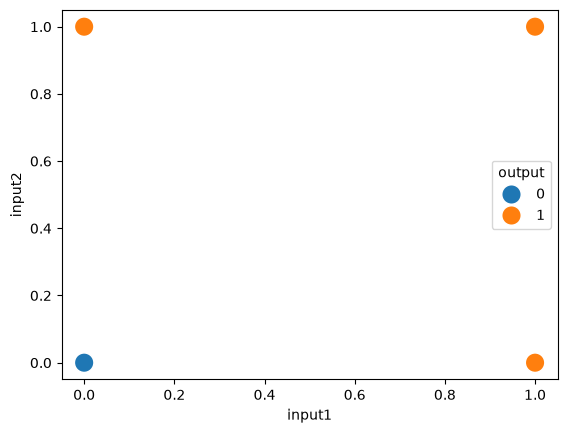

In [7]:
sns.scatterplot(x=or_data['input1'],y=or_data['input2'], hue=or_data['output'], s=200)

<Axes: xlabel='input1', ylabel='input2'>

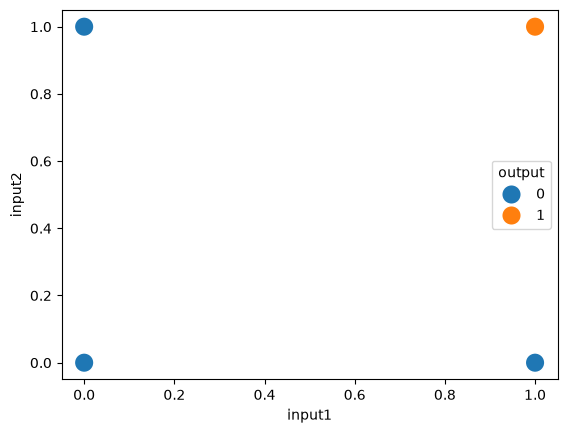

In [8]:
sns.scatterplot(x=and_data['input1'],y=and_data['input2'], hue=and_data['output'], s=200)

<Axes: xlabel='input1', ylabel='input2'>

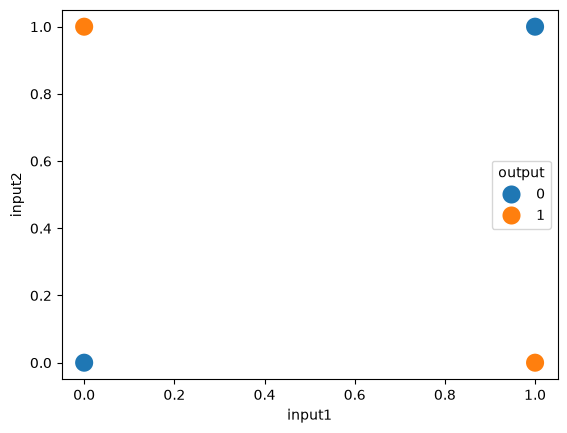

In [9]:
sns.scatterplot(x=xor_data['input1'],y=xor_data['input2'], hue=xor_data['output'], s=200)

create perceptron classifier

In [21]:
from sklearn.linear_model import Perceptron
class_or=Perceptron()
class_and=Perceptron()
class_xor=Perceptron()

In [22]:
class_or.fit(or_data.iloc[:,:-1].values, or_data.iloc[:,-1].values)
class_and.fit(and_data.iloc[:,:-1].values, and_data.iloc[:,-1].values)
class_xor.fit(xor_data.iloc[:,:-1].values, xor_data.iloc[:,-1].values)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [23]:
print(class_or.coef_, class_and.coef_, class_xor.coef_)

[[2. 2.]] [[2. 2.]] [[0. 0.]]


In [24]:
print(class_or.intercept_, class_and.intercept_, class_xor.intercept_)

[-1.] [-2.] [0.]


In [14]:
print(class_or.classes_, class_and.classes_, class_xor.classes_)

[0 1] [0 1] [0 1]


### Limitation of perceptron

- it is easily able to create the linear decision boundaries but  non-linear functions, it won't be able to create the boundary

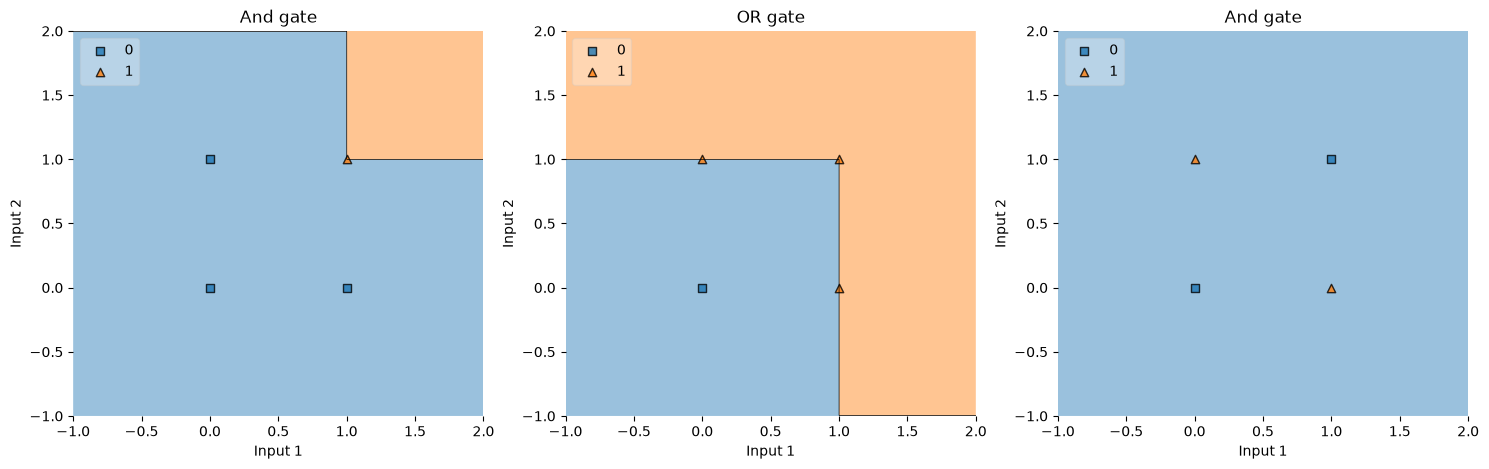

In [25]:
from mlxtend.plotting import plot_decision_regions

fig, axes=plt.subplots(1,3, figsize=(18, 5))

axes[0].set_title('And gate')
plot_decision_regions(X=and_data.iloc[:,:-1].values, y=and_data.iloc[:,-1].values, clf=class_and, legend=2, ax=axes[0])
axes[0].set_xlabel('Input 1')
axes[0].set_ylabel('Input 2')

axes[1].set_title('OR gate')
plot_decision_regions(X=or_data.iloc[:,:-1].values, y=or_data.iloc[:,-1].values, clf=class_or, legend=2, ax=axes[1])
axes[1].set_xlabel('Input 1')
axes[1].set_ylabel('Input 2')

axes[2].set_title('And gate')
plot_decision_regions(X=xor_data.iloc[:,:-1].values, y=xor_data.iloc[:,-1].values, clf=class_xor, legend=2, ax=axes[2])
axes[2].set_xlabel('Input 1')
axes[2].set_ylabel('Input 2')
plt.show()